In [64]:
import pandas as pd


In [65]:
df=pd.read_csv('QueryResults.csv',names=['DATE','TAG','POST'],header=0)



In [66]:
df.head()


,DATE,TAG,POST
0,2008-07-01 00:00:00,c#,3
1,2008-08-01 00:00:00,assembly,8
2,2008-08-01 00:00:00,javascript,162
3,2008-08-01 00:00:00,c,85
4,2008-08-01 00:00:00,python,124


In [67]:
df.tail()

,DATE,TAG,POST
1986,2020-07-01 00:00:00,r,5694
1987,2020-07-01 00:00:00,go,743
1988,2020-07-01 00:00:00,ruby,775
1989,2020-07-01 00:00:00,perl,182
1990,2020-07-01 00:00:00,swift,3607


In [68]:
df.shape


(1991, 3)

In [69]:
df.count()

DATE    1991
TAG     1991
POST    1991
dtype: int64

In [70]:
df.groupby('TAG').sum()

,DATE,POST
TAG,,
assembly,2008-08-01 00:00:002008-09-01 00:00:002008-10-...,34852
c,2008-08-01 00:00:002008-09-01 00:00:002008-10-...,336042
c#,2008-07-01 00:00:002008-08-01 00:00:002008-09-...,1423530
c++,2008-08-01 00:00:002008-09-01 00:00:002008-10-...,684210
delphi,2008-08-01 00:00:002008-09-01 00:00:002008-10-...,46212
go,2009-11-01 00:00:002009-12-01 00:00:002010-01-...,47499
java,2008-08-01 00:00:002008-09-01 00:00:002008-10-...,1696403
javascript,2008-08-01 00:00:002008-09-01 00:00:002008-10-...,2056510
perl,2008-08-01 00:00:002008-09-01 00:00:002008-10-...,65286


In [71]:
df.groupby('TAG').count()

,DATE,POST
TAG,,
assembly,144,144
c,144,144
c#,145,145
c++,144,144
delphi,144,144
go,129,129
java,144,144
javascript,144,144
perl,144,144


In [72]:
df.DATE[1]

'2008-08-01 00:00:00'

In [73]:
type(df['DATE'][1])

str

In [74]:
pd.to_datetime(df.DATE[1])
type(pd.to_datetime(df.DATE[1]))

pandas._libs.tslibs.timestamps.Timestamp

In [75]:
#DATA CLEANING
# CHANGE TYPE OF STR TO DATETIME

df.DATE=pd.to_datetime(df.DATE)
df.head()

,DATE,TAG,POST
0,2008-07-01,c#,3
1,2008-08-01,assembly,8
2,2008-08-01,javascript,162
3,2008-08-01,c,85
4,2008-08-01,python,124


In [76]:
## Data Manpulation:pivoting dataframe

In [77]:
test_df=pd.DataFrame({'Age':['Young','Young','Young','Young','Old','Old','Old','Old'],
                      'Actor': ['Jack', 'Arnold', 'Keanu', 'Sylvester', 'Jack', 'Arnold', 'Keanu', 'Sylvester'],
                      'Power':[100,80,25,50,99,75,5,30]})

In [78]:
test_df

,Age,Actor,Power
0,Young,Jack,100
1,Young,Arnold,80
2,Young,Keanu,25
3,Young,Sylvester,50
4,Old,Jack,99
5,Old,Arnold,75
6,Old,Keanu,5
7,Old,Sylvester,30


In [79]:
pivoted_df=test_df.pivot(index='Age',columns='Actor',values='Power')

In [80]:
pivoted_df

Actor,Arnold,Jack,Keanu,Sylvester
Age,,,,
Old,75,99,5,30
Young,80,100,25,50


In [81]:
reshaped_df=df.pivot(index='DATE',columns='TAG',values='POST')

In [82]:
reshaped_df


TAG,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
DATE,,,,,,,,,,,,,,
2008-07-01,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-08-01,8.0,85.0,511.0,164.0,14.0,NaN,222.0,162.0,28.0,161.0,124.0,NaN,73.0,NaN
2008-09-01,28.0,321.0,1649.0,755.0,105.0,NaN,1137.0,640.0,131.0,482.0,542.0,6.0,290.0,NaN
2008-10-01,15.0,303.0,1989.0,811.0,112.0,NaN,1153.0,725.0,127.0,617.0,510.0,NaN,249.0,NaN
2008-11-01,17.0,259.0,1730.0,735.0,141.0,NaN,958.0,579.0,97.0,504.0,452.0,1.0,160.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-01,317.0,2670.0,8954.0,5107.0,181.0,719.0,13253.0,20483.0,215.0,6672.0,26673.0,5761.0,780.0,3434.0
2020-04-01,406.0,3472.0,10042.0,6820.0,250.0,887.0,15377.0,24634.0,240.0,8060.0,32605.0,7047.0,860.0,4015.0
2020-05-01,386.0,3602.0,9923.0,7063.0,221.0,826.0,14711.0,25196.0,228.0,7917.0,34478.0,6833.0,774.0,4066.0


In [83]:
reshaped_df.shape

(145, 14)

In [84]:
reshaped_df.columns

Index(['assembly', 'c', 'c#', 'c++', 'delphi', 'go', 'java', 'javascript',
       'perl', 'php', 'python', 'r', 'ruby', 'swift'],
      dtype='object', name='TAG')

In [85]:
reshaped_df.head()

TAG,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
DATE,,,,,,,,,,,,,,
2008-07-01,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-08-01,8.0,85.0,511.0,164.0,14.0,NaN,222.0,162.0,28.0,161.0,124.0,NaN,73.0,NaN
2008-09-01,28.0,321.0,1649.0,755.0,105.0,NaN,1137.0,640.0,131.0,482.0,542.0,6.0,290.0,NaN
2008-10-01,15.0,303.0,1989.0,811.0,112.0,NaN,1153.0,725.0,127.0,617.0,510.0,NaN,249.0,NaN
2008-11-01,17.0,259.0,1730.0,735.0,141.0,NaN,958.0,579.0,97.0,504.0,452.0,1.0,160.0,NaN


In [86]:
reshaped_df.count()

TAG
assembly      144
c             144
c#            145
c++           144
delphi        144
go            129
java          144
javascript    144
perl          144
php           144
python        144
r             142
ruby          144
swift         135
dtype: int64

In [89]:
reshaped_df.isna().values.any()

True

In [91]:
reshaped_df.fillna(0,inplace=True)

In [92]:
reshaped_df

TAG,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
DATE,,,,,,,,,,,,,,
2008-07-01,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2008-08-01,8.0,85.0,511.0,164.0,14.0,0.0,222.0,162.0,28.0,161.0,124.0,0.0,73.0,0.0
2008-09-01,28.0,321.0,1649.0,755.0,105.0,0.0,1137.0,640.0,131.0,482.0,542.0,6.0,290.0,0.0
2008-10-01,15.0,303.0,1989.0,811.0,112.0,0.0,1153.0,725.0,127.0,617.0,510.0,0.0,249.0,0.0
2008-11-01,17.0,259.0,1730.0,735.0,141.0,0.0,958.0,579.0,97.0,504.0,452.0,1.0,160.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-01,317.0,2670.0,8954.0,5107.0,181.0,719.0,13253.0,20483.0,215.0,6672.0,26673.0,5761.0,780.0,3434.0
2020-04-01,406.0,3472.0,10042.0,6820.0,250.0,887.0,15377.0,24634.0,240.0,8060.0,32605.0,7047.0,860.0,4015.0
2020-05-01,386.0,3602.0,9923.0,7063.0,221.0,826.0,14711.0,25196.0,228.0,7917.0,34478.0,6833.0,774.0,4066.0


In [93]:
reshaped_df.count()

TAG
assembly      145
c             145
c#            145
c++           145
delphi        145
go            145
java          145
javascript    145
perl          145
php           145
python        145
r             145
ruby          145
swift         145
dtype: int64

In [94]:
reshaped_df.isna().values.any()

False

In [102]:
import matplotlib.pyplot as plt

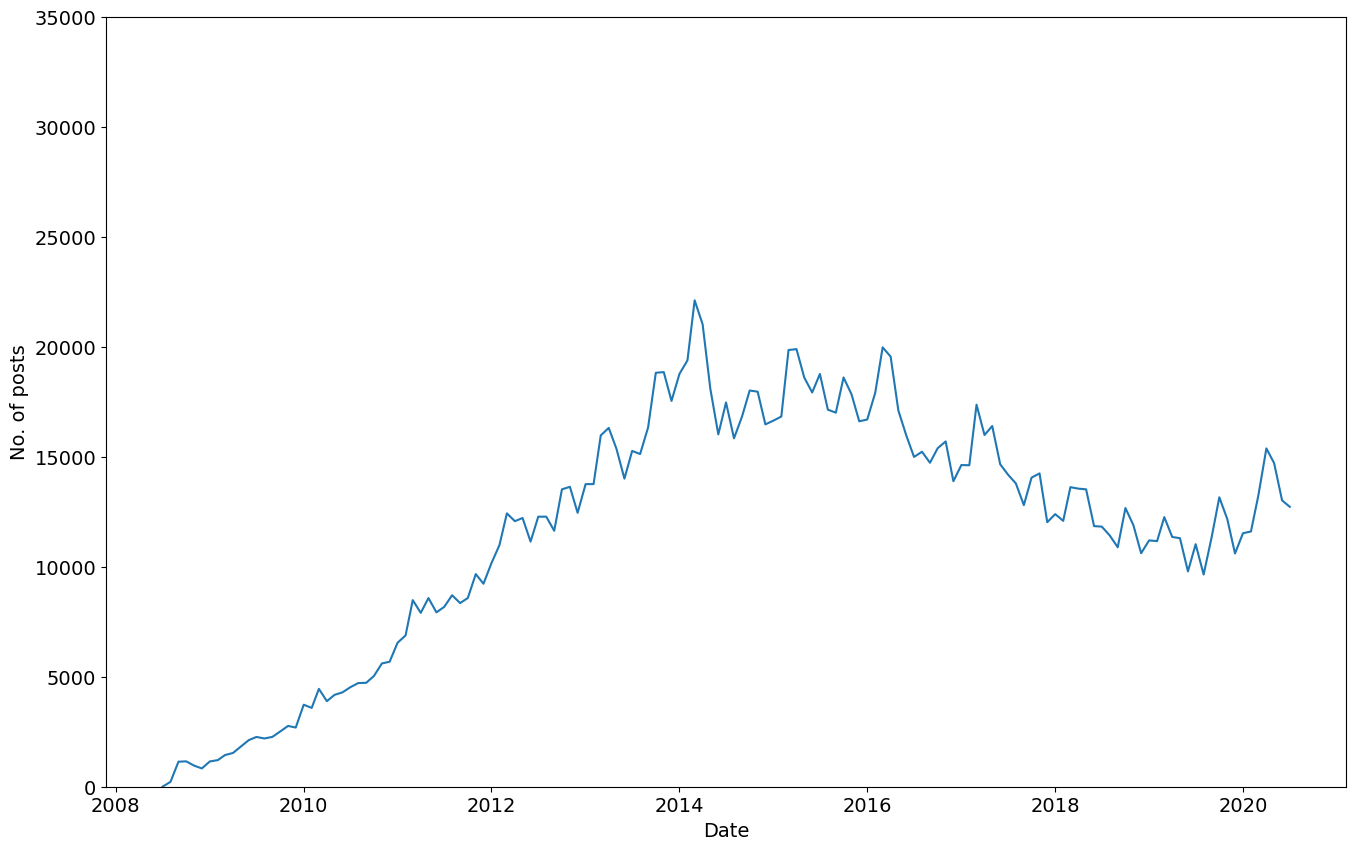

In [119]:
plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Date',fontsize=14)
plt.ylabel('No. of posts', fontsize=14)
plt.ylim(0, 35000)
plt.plot(reshaped_df.index,reshaped_df.java)

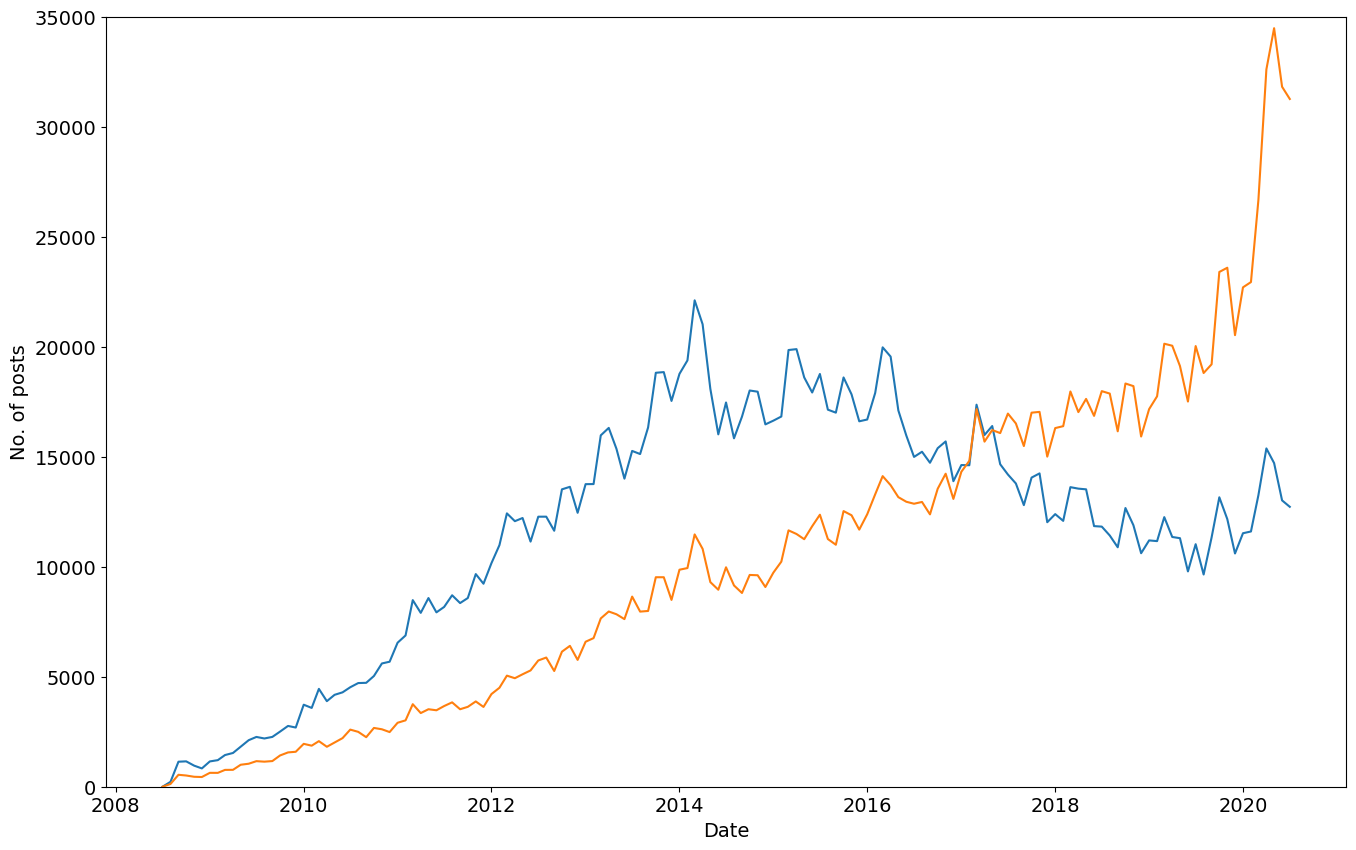

In [123]:
#multline charts
plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Date',fontsize=14)
plt.ylabel('No. of posts', fontsize=14)
plt.ylim(0, 35000)
plt.plot(reshaped_df.index,reshaped_df.java)
plt.plot(reshaped_df.index,reshaped_df.python)

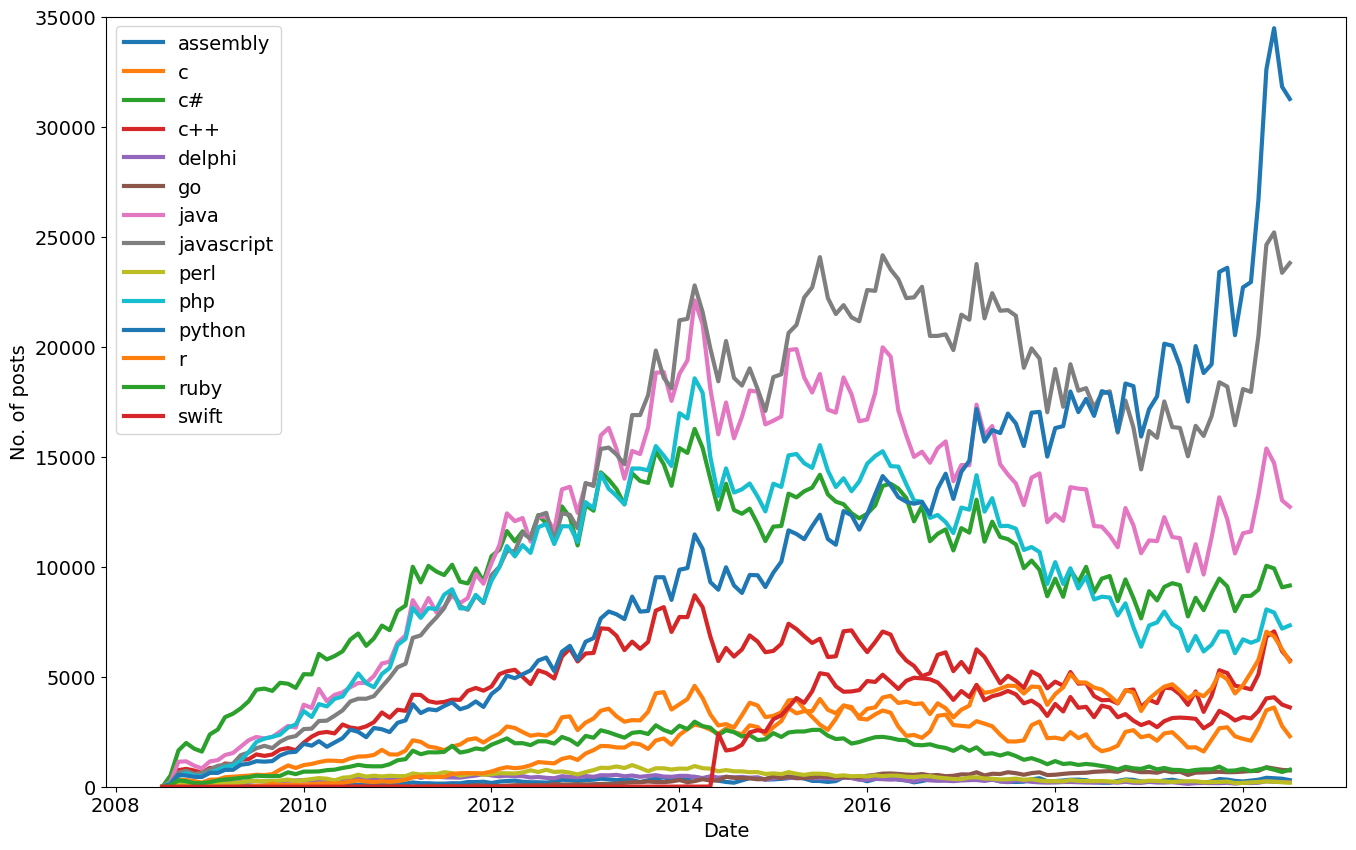

In [128]:
#multline charts of all lanaguage using loop
plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Date',fontsize=14)
plt.ylabel('No. of posts', fontsize=14)
plt.ylim(0, 35000)
for column in reshaped_df.columns:
    plt.plot(reshaped_df.index,reshaped_df[column],
            linewidth=3, label=reshaped_df[column].name)

plt.legend(fontsize=14)
    



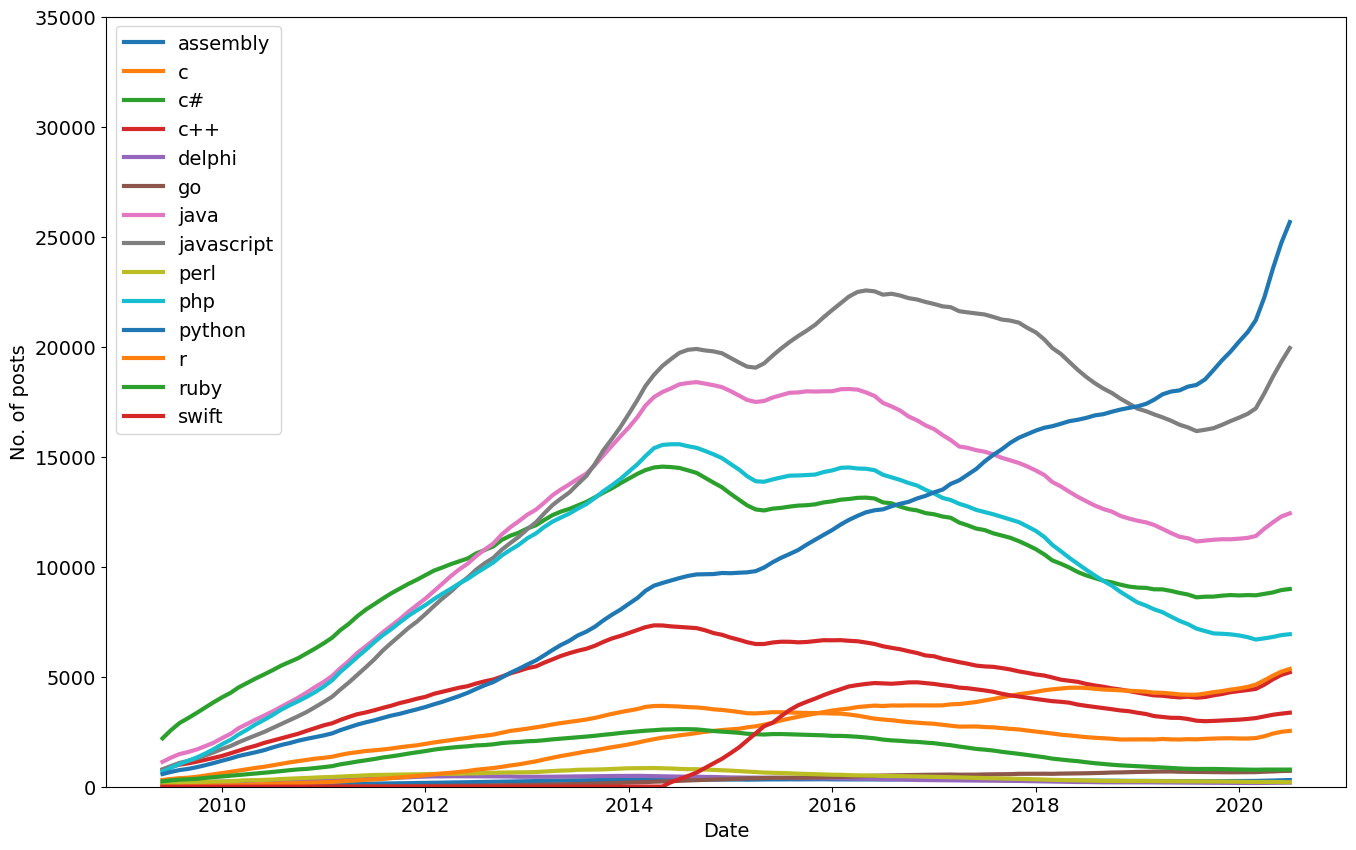

In [132]:
rolled_df=reshaped_df.rolling(window=12).mean()
plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Date',fontsize=14)
plt.ylabel('No. of posts',fontsize=14)
plt.ylim(0,35000)

for column in rolled_df.columns:
    plt.plot(rolled_df.index,rolled_df[column],linewidth=3,label=rolled_df[column].name)

plt.legend(fontsize=14)


In [157]:
filtered_data=df[(df.DATE >= '2008-01-01') & (df.DATE <= '2012-12-31')]
language_count=filtered_data.TAG.value_counts()
# Get the most popular language
most_popular_language = language_count.idxmax()
most_popular_count = language_count.max()

print(f"The most popular programming language from 2008 to 2012 is {most_popular_language} with {most_popular_count} posts.")

The most popular programming language from 2008 to 2012 is c# with 54 posts.


In [158]:
language_count

TAG
c#            54
assembly      53
javascript    53
c             53
python        53
perl          53
c++           53
java          53
delphi        53
ruby          53
php           53
r             51
swift         44
go            38
Name: count, dtype: int64

In [160]:
filtered_data1=df[(df.DATE >= '2015-01-01') & (df.DATE <= '2018-12-31')]
filtered_data1.TAG.value_counts()

TAG
javascript    48
c             48
c#            48
assembly      48
java          48
c++           48
delphi        48
php           48
go            48
perl          48
python        48
r             48
ruby          48
swift         48
Name: count, dtype: int64

In [161]:
filtered_data2=df[(df.DATE >= '2020-01-01') & (df.DATE <= '2020-12-31')]
filtered_data2.TAG.value_counts()

TAG
assembly      7
c#            7
c             7
python        7
java          7
delphi        7
perl          7
c++           7
r             7
go            7
ruby          7
javascript    7
swift         7
php           7
Name: count, dtype: int64

In [164]:
filtered_data2


,DATE,TAG,POST
1893,2020-01-01,assembly,239
1894,2020-01-01,c#,8665
1895,2020-01-01,c,2177
1896,2020-01-01,python,22699
1897,2020-01-01,java,11522
...,...,...,...
1986,2020-07-01,r,5694
1987,2020-07-01,go,743
1988,2020-07-01,ruby,775
1989,2020-07-01,perl,182
